# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [ ]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("../data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [7]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()
clean = df.copy()
print("Shape:", clean.shape)
print("\nData types:")
print(clean.dtypes)

print("\nMissing Values")
print(clean.isna().sum())

print("\nDuplicate rows:", clean.duplicated().sum())


Shape: (11914, 15)

Data types:
Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

Missing Values
Make                  0
Model                 0
Year                  0
Engine Fuel Type      3
Engine HP            69
Engine Cylinders     30
Transmission Type     0
Driven_Wheels         0
Number of Doors       6
Vehicle Size          0
Vehicle Style         0
highway MPG           0
city mpg              0
Popularity            0
MSRP                  0
dtype: int64

Duplicate rows: 720


In [8]:
display(clean.describe())

for col in clean.columns:
    print(f"\n{col}")
    print(clean[col].value_counts(dropna=False).head(10))

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06



Make
Make
Chevrolet     1123
Ford           881
Volkswagen     809
Toyota         746
Dodge          626
Nissan         558
GMC            515
Honda          449
Mazda          423
Cadillac       397
Name: count, dtype: int64

Model
Model
Silverado 1500        156
Tundra                140
F-150                 126
Sierra 1500            90
Beetle Convertible     89
Tacoma                 80
GTI                    76
Frontier               76
Accord                 75
Beetle                 75
Name: count, dtype: int64

Year
Year
2015    2170
2016    2157
2017    1668
2014     589
2012     387
2009     379
2013     366
2008     349
2007     345
2010     298
Name: count, dtype: int64

Engine Fuel Type
Engine Fuel Type
regular unleaded                                7172
premium unleaded (required)                     2009
premium unleaded (recommended)                  1523
flex-fuel (unleaded/E85)                         899
diesel                                           154
electri

In [9]:
# Prices
display(clean.nlargest(10, "MSRP"))

# Horsepower
display(clean.nlargest(10, "Engine HP"))

# Missing values by vehicle make
display(clean.groupby("Make")["Engine HP"].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head(15))

# Check whether popularity varies within the same make
display(clean.groupby("Make")["Popularity"].nunique().sort_values(ascending=False))

# Check possible duplicate vehicles
display(clean[clean.duplicated(keep=False)].head(20))

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11362,Bugatti,Veyron 16.4,2008,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,Compact,Coupe,14,8,820,2065902
11364,Bugatti,Veyron 16.4,2009,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,Compact,Coupe,14,8,820,1705769
8486,Lamborghini,Reventon,2008,premium unleaded (required),650.0,12.0,AUTOMATED_MANUAL,all wheel drive,2.0,Compact,Coupe,14,9,1158,1500000
11363,Bugatti,Veyron 16.4,2008,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,Compact,Coupe,14,8,820,1500000
6351,Maybach,Landaulet,2012,premium unleaded (required),620.0,12.0,AUTOMATIC,rear wheel drive,4.0,Large,Convertible,16,10,67,1382750
6350,Maybach,Landaulet,2011,premium unleaded (required),620.0,12.0,AUTOMATIC,rear wheel drive,4.0,Large,Convertible,16,10,67,1380000
4024,Ferrari,Enzo,2003,premium unleaded (required),660.0,12.0,AUTOMATED_MANUAL,rear wheel drive,2.0,Compact,Coupe,12,7,2774,643330
1622,Lamborghini,Aventador,2014,premium unleaded (required),720.0,12.0,AUTOMATED_MANUAL,all wheel drive,2.0,Midsize,Convertible,16,10,1158,548800
1626,Lamborghini,Aventador,2015,premium unleaded (required),720.0,12.0,AUTOMATED_MANUAL,all wheel drive,2.0,Midsize,Convertible,16,10,1158,548800
1629,Lamborghini,Aventador,2016,premium unleaded (required),750.0,12.0,AUTOMATED_MANUAL,all wheel drive,2.0,Midsize,Convertible,18,11,1158,535500


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11362,Bugatti,Veyron 16.4,2008,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,Compact,Coupe,14,8,820,2065902
11363,Bugatti,Veyron 16.4,2008,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,Compact,Coupe,14,8,820,1500000
11364,Bugatti,Veyron 16.4,2009,premium unleaded (required),1001.0,16.0,AUTOMATED_MANUAL,all wheel drive,2.0,Compact,Coupe,14,8,820,1705769
1629,Lamborghini,Aventador,2016,premium unleaded (required),750.0,12.0,AUTOMATED_MANUAL,all wheel drive,2.0,Midsize,Convertible,18,11,1158,535500
1630,Lamborghini,Aventador,2016,premium unleaded (required),750.0,12.0,AUTOMATED_MANUAL,all wheel drive,2.0,Midsize,Coupe,18,11,1158,490700
4644,Ferrari,F12 Berlinetta,2013,premium unleaded (required),731.0,12.0,AUTOMATED_MANUAL,rear wheel drive,2.0,Midsize,Coupe,16,11,2774,315888
4645,Ferrari,F12 Berlinetta,2014,premium unleaded (required),731.0,12.0,AUTOMATED_MANUAL,rear wheel drive,2.0,Midsize,Coupe,16,11,2774,315888
4646,Ferrari,F12 Berlinetta,2015,premium unleaded (required),731.0,12.0,AUTOMATED_MANUAL,rear wheel drive,2.0,Midsize,Coupe,16,11,2774,319995
1622,Lamborghini,Aventador,2014,premium unleaded (required),720.0,12.0,AUTOMATED_MANUAL,all wheel drive,2.0,Midsize,Convertible,16,10,1158,548800
1623,Lamborghini,Aventador,2014,premium unleaded (required),720.0,12.0,AUTOMATED_MANUAL,all wheel drive,2.0,Midsize,Coupe,18,11,1158,497650


Make
Tesla            18
Ford             13
Nissan           10
Lincoln           8
Chevrolet         6
Kia               5
FIAT              3
Toyota            2
Honda             2
Mercedes-Benz     1
Mitsubishi        1
Acura             0
Plymouth          0
Mazda             0
McLaren           0
Name: Engine HP, dtype: int64

Make
Acura            1
Alfa Romeo       1
Lotus            1
Maserati         1
Maybach          1
Mazda            1
McLaren          1
Mercedes-Benz    1
Mitsubishi       1
Nissan           1
Oldsmobile       1
Plymouth         1
Pontiac          1
Porsche          1
Rolls-Royce      1
Saab             1
Scion            1
Spyker           1
Subaru           1
Suzuki           1
Tesla            1
Toyota           1
Volkswagen       1
Lincoln          1
Lexus            1
Land Rover       1
Dodge            1
Aston Martin     1
Audi             1
BMW              1
Bentley          1
Bugatti          1
Buick            1
Cadillac         1
Chevrolet        1
Chrysler         1
FIAT             1
Lamborghini      1
Ferrari          1
Ford             1
GMC              1
Genesis          1
HUMMER           1
Honda            1
Hyundai          1
Infiniti         1
Kia              1
Volvo            1
Name: Popularity, dtype: int64

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11,BMW,1 Series,2013,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,19,3916,31500
14,BMW,1 Series,2013,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,19,3916,31500
17,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,24,17,3105,2000
18,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,24,17,3105,2000
20,Audi,100,1992,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,24,17,3105,2000
22,Audi,100,1993,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,24,17,3105,2000
24,Audi,100,1993,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,24,17,3105,2000
25,Audi,100,1993,regular unleaded,172.0,6.0,MANUAL,front wheel drive,4.0,Midsize,Sedan,24,17,3105,2000
87,Nissan,200SX,1996,regular unleaded,115.0,4.0,MANUAL,front wheel drive,2.0,Compact,Coupe,36,26,2009,2000
88,Nissan,200SX,1996,regular unleaded,115.0,4.0,MANUAL,front wheel drive,2.0,Compact,Coupe,36,26,2009,2000


**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | Duplicate rows | `duplicated().sum()` | 720 | Dropped duplicates | Avoid counting the same cars multiple times |
| 2 | Missing horsepower | `isna().sum()` | 69 | Kept as NaN | Don't want to guess missing values |
| 3 | Missing engine cylinders | `isna().sum()` | 30 | Kept as NaN | Some may be electric vehicles, so missing values aren't necessarily errors |
| 4 | Missing number of doors | `isna().sum()` | 6 | Kept as NaN | Avoid making up door counts |
| 5 | Suspicious MSRP values ($2,000) | `value_counts()` | TBD | Investigating; may replace with NaN | Could be placeholder prices that affect averages |

In [14]:
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")
clean = clean.drop_duplicates()

# Check suspicious prices
print(clean["msrp"].value_counts().head(15))

display(
    clean[clean["msrp"] == 2000][
        ["make", "model", "year", "msrp"]
    ].head(20)
)

# Check missing cylinders by fuel type
display(
    clean.groupby("engine_fuel_type", dropna=False)["engine_cylinders"]
    .apply(lambda x: x.isna().sum())
)

# Check unusual cylinder values
print(clean["engine_cylinders"].value_counts(dropna=False))

# Check popularity inconsistencies
display(
    clean.groupby("make")["popularity"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

# Check unusually high fuel economy
display(
    clean.nlargest(15, "highway_mpg")[
        ["make", "model", "engine_fuel_type", "highway_mpg", "city_mpg"]
    ]
)

msrp
2000     747
29995     18
25995     17
27995     15
20995     15
24995     14
21995     14
30995     13
23995     12
22995     12
49800     11
43950     10
24895     10
15995      9
39995      9
Name: count, dtype: int64


,make,model,year,msrp
17,Audi,100,1992,2000
19,Audi,100,1992,2000
21,Audi,100,1992,2000
22,Audi,100,1993,2000
23,Audi,100,1993,2000
26,Audi,100,1993,2000
27,Audi,100,1994,2000
28,Audi,100,1994,2000
29,Audi,100,1994,2000
30,Audi,100,1994,2000


engine_fuel_type
diesel                                           0
electric                                        10
flex-fuel (premium unleaded recommended/E85)     0
flex-fuel (premium unleaded required/E85)        0
flex-fuel (unleaded/E85)                         0
flex-fuel (unleaded/natural gas)                 0
natural gas                                      0
premium unleaded (recommended)                   0
premium unleaded (required)                     17
regular unleaded                                 3
NaN                                              0
Name: engine_cylinders, dtype: int64

engine_cylinders
4.0     4361
6.0     4288
8.0     1964
12.0     228
5.0      169
10.0      65
0.0       56
NaN       30
3.0       30
16.0       3
Name: count, dtype: int64


make
Acura            1
Alfa Romeo       1
Lotus            1
Maserati         1
Maybach          1
Mazda            1
McLaren          1
Mercedes-Benz    1
Mitsubishi       1
Nissan           1
Oldsmobile       1
Plymouth         1
Pontiac          1
Porsche          1
Rolls-Royce      1
Name: popularity, dtype: int64

,make,model,engine_fuel_type,highway_mpg,city_mpg
1119,Audi,A6,premium unleaded (recommended),354,24
5790,BMW,i3,electric,111,137
5791,BMW,i3,electric,111,137
5792,BMW,i3,electric,111,137
1983,Chevrolet,Bolt EV,electric,110,128
1984,Chevrolet,Bolt EV,electric,110,128
9867,Chevrolet,Spark EV,electric,109,128
9868,Chevrolet,Spark EV,electric,109,128
9869,Chevrolet,Spark EV,electric,109,128
9870,Chevrolet,Spark EV,electric,109,128


In [15]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11194, 15)
engine_fuel_type     3
engine_hp           69
engine_cylinders    30
number_of_doors      6
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Mean MSRP: 41,933.29
Median MSRP: 30,675.00


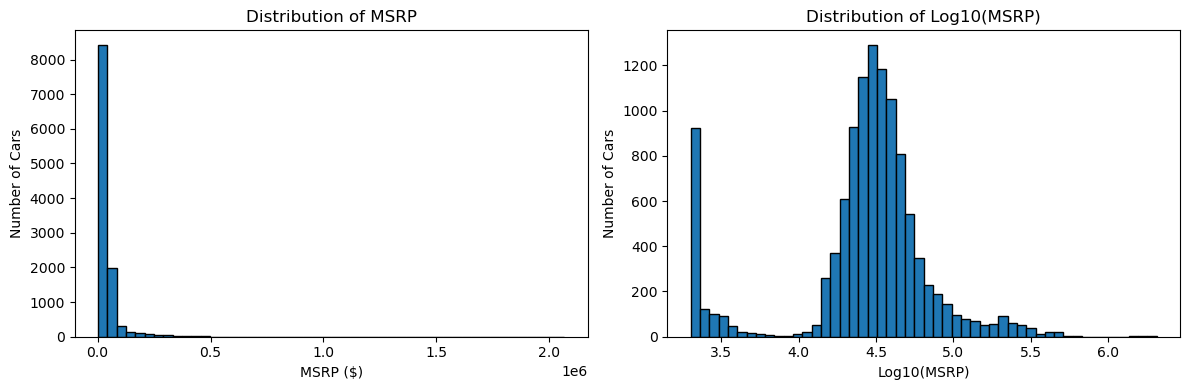

Cars above the mean: 26.68%


In [18]:
# a) mean and median
mean_msrp = clean["msrp"].mean()
median_msrp = clean["msrp"].median()

print(f"Mean MSRP: {mean_msrp:,.2f}")
print(f"Median MSRP: {median_msrp:,.2f}")

# b) two histograms side by side (plt.subplots(1, 2))
msrp = clean["msrp"].dropna()
msrp = msrp[msrp > 0] # positive values for the log function

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(msrp, bins=50, edgecolor="black")
axes[0].set_title("Distribution of MSRP")
axes[0].set_xlabel("MSRP ($)")
axes[0].set_ylabel("Number of Cars")

axes[1].hist(np.log10(msrp), bins=50, edgecolor="black")
axes[1].set_title("Distribution of Log10(MSRP)")
axes[1].set_xlabel("Log10(MSRP)")
axes[1].set_ylabel("Number of Cars")

plt.tight_layout()
plt.show()

# c) share of cars above the mean
percent_above = (msrp > mean_msrp).mean() * 100
print(f"Cars above the mean: {percent_above:.2f}%")

**Answer:** <br>
a) The mean is bigger because a small number of very expensive luxury cars pull the average upward <br>
b) The original MSRP distribution is right-skewed, with most cars at lower prices and a few extremely expensive cars. The log-transformed distribution is less skewed and easier to visualize. <br>
c) 26.68% <br>
d) I would use the median because it better represents the price of a typical car. The mean is influened by a small number of extremely expensive vehicles.

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [19]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
cars_2017 = clean[
    (clean["year"] == 2017) &
    (clean["highway_mpg"].notna()) &
    (clean["highway_mpg"] > 0)
]

stats = cars_2017.groupby("vehicle_size")["highway_mpg"].agg(["mean", "std"])

display(stats)

# b) z = (value - class mean) / class std
civic_mpg = 42
volvo_mpg = 34

civic_mean = stats.loc["Compact", "mean"]
civic_std = stats.loc["Compact", "std"]

volvo_mean = stats.loc["Large", "mean"]
volvo_std = stats.loc["Large", "std"]

civic_z = (civic_mpg - civic_mean) / civic_std
volvo_z = (volvo_mpg - volvo_mean) / volvo_std

print(f"Honda Civic z-score: {civic_z:.2f}")
print(f"Volvo S90 z-score: {volvo_z:.2f}")

,mean,std
vehicle_size,,
Compact,31.994197,10.784983
Large,22.991453,3.491184
Midsize,29.918623,13.948504


Honda Civic z-score: 0.93
Volvo S90 z-score: 3.15


**Answer:** <br>
c) The Volvo S90 is more fuel-efficient for its class because it has a higher z-score of 3.15, compared to the Honda Civic's 0.93. This means the Volvo is 3.15 standard deviations above the average large car, making it very unusual, while the Civic is only 0.93 standard deviations above the average compact car.

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

2017 Median MSRP: $36,737.50
95% CI: $35,912.50 - $37,685.00


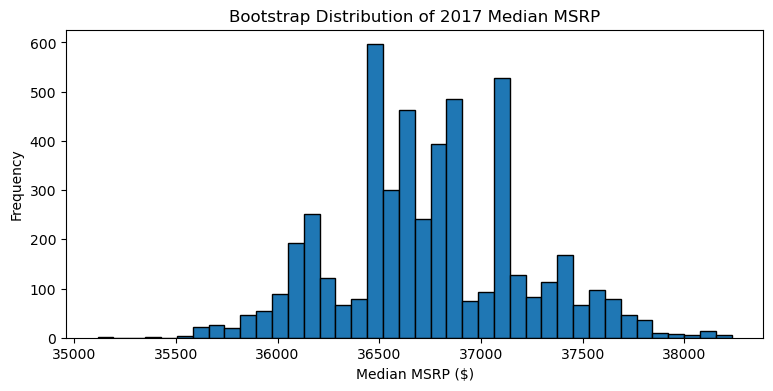

Makes with fewer than 50 cars:
make
Subaru        46
Lincoln       46
Kia           43
Hyundai       42
Buick         39
Acura         36
Lexus         34
Mitsubishi    29
Infiniti      28
Porsche       25
Mazda         24
Chrysler      24
Volvo         23
FIAT          19
Land Rover    11
Maserati      10
Genesis        3
Lotus          1
Name: count, dtype: int64
Mazda 95% CI: $21,577.50 - $23,895.00
All cars CI width: $1,772.50
Mazda CI width: $2,317.50


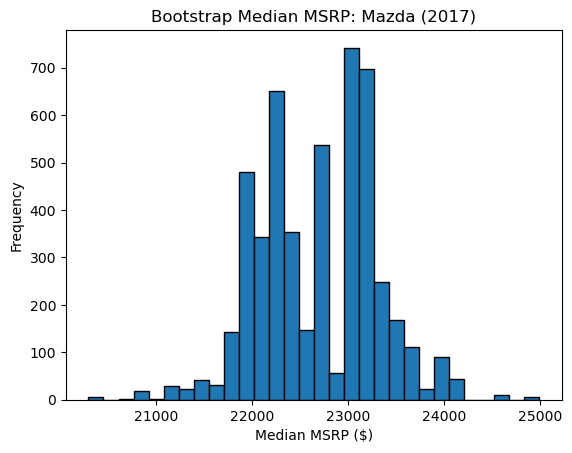

In [22]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    values = np.asarray(values)
    medians = []

    for i in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        medians.append(np.median(sample))

    return np.array(medians)

# a, b)
cars_2017 = clean[
    (clean["year"] == 2017) &
    (clean["msrp"].notna())
]

prices_2017 = cars_2017["msrp"].to_numpy()

print(f"2017 Median MSRP: ${np.median(prices_2017):,.2f}")

boot_medians = bootstrap_median(prices_2017)

ci_2017 = np.percentile(boot_medians, [2.5, 97.5])

print(f"95% CI: ${ci_2017[0]:,.2f} - ${ci_2017[1]:,.2f}")

plt.figure(figsize=(9, 4))
plt.hist(boot_medians, bins=40, edgecolor="black")
plt.title("Bootstrap Distribution of 2017 Median MSRP")
plt.xlabel("Median MSRP ($)")
plt.ylabel("Frequency")
plt.show()

# c)
make_counts = cars_2017["make"].value_counts()

print("Makes with fewer than 50 cars:")
print(make_counts[make_counts < 50])

# Choose Mazda:
selected_make = "Mazda"

make_prices = cars_2017.loc[
    cars_2017["make"] == selected_make, "msrp"
].to_numpy()

make_boot = bootstrap_median(make_prices)
make_ci = np.percentile(make_boot, [2.5, 97.5])

print(f"Mazda 95% CI: ${make_ci[0]:,.2f} - ${make_ci[1]:,.2f}")
print(f"All cars CI width: ${np.ptp(ci_2017):,.2f}")
print(f"Mazda CI width: ${np.ptp(make_ci):,.2f}")

plt.hist(make_boot, bins=30, edgecolor="black")
plt.title("Bootstrap Median MSRP: Mazda (2017)")
plt.xlabel("Median MSRP ($)")
plt.ylabel("Frequency")
plt.show()

**Answer:** <br>
c) I chose Mazda, which has 24 cars in 2017. Its 95% confidence interval is [insert interval]. Compared to all 2017 cars, its interval is [wider/narrower]. A smaller sample generally creates more uncertainty because we have fewer observations, although the spread of prices also matters. <br>
d) Based on our data, we are 95% confident that the median MSRP for 2017 cars is between $35,929.81 and $37,685.00.

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

Sample size: 517
Mean MPG: 31.994197292069632
Standard deviation: 10.784982973384531


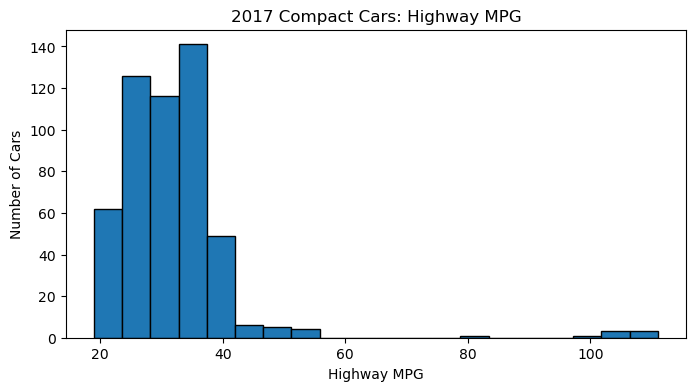


Original t-test:
t-statistic: 4.2043
p-value: 0.000015
Reject H0: Evidence that mean MPG exceeds 30.

Rows per make + model:


make           model                 
Toyota         Tacoma                    27
Chevrolet      Corvette                  24
Nissan         Frontier                  22
               370Z                      17
Porsche        911                       14
                                         ..
Ford           Focus RS                   1
FIAT           500e                       1
Mitsubishi     i-MiEV                     1
Mercedes-Benz  B-Class Electric Drive     1
Ford           Focus ST                   1
Length: 90, dtype: int64


Number of unique models: 90
Mean MPG across models: 35.62398018043443

Model-level t-test:
t-statistic: 3.0963
p-value: 0.001310
Reject H0: Evidence that mean MPG exceeds 30.


In [24]:
from scipy import stats

# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
compact = clean[
    (clean["year"] == 2017) &
    (clean["vehicle_size"] == "Compact") &
    (clean["highway_mpg"].notna()) &
    (clean["highway_mpg"] > 0)
].copy()

print("Sample size:", len(compact))
print("Mean MPG:", compact["highway_mpg"].mean())
print("Standard deviation:", compact["highway_mpg"].std())

plt.figure(figsize=(8, 4))
plt.hist(compact["highway_mpg"], bins=20, edgecolor="black")
plt.title("2017 Compact Cars: Highway MPG")
plt.xlabel("Highway MPG")
plt.ylabel("Number of Cars")
plt.show()

# c) one-sample t-test vs 30
t_stat, p_value = stats.ttest_1samp(
    compact["highway_mpg"],
    popmean=30,
    alternative="greater"
)

print("\nOriginal t-test:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Reject H0: Evidence that mean MPG exceeds 30.")
else:
    print("Fail to reject H0: Not enough evidence that mean MPG exceeds 30.")

# d) rows per make+model, then one row per model and retest
model_counts = (
    compact.groupby(["make", "model"])
    .size()
    .sort_values(ascending=False)
)

print("\nRows per make + model:")
display(model_counts)

# Average MPG to one row per model
model_avg = (
    compact.groupby(["make", "model"], as_index=False)
    ["highway_mpg"].mean()
)

print("\nNumber of unique models:", len(model_avg))
print("Mean MPG across models:", model_avg["highway_mpg"].mean())

# Rerun t-test using model averages
t_model, p_model = stats.ttest_1samp(
    model_avg["highway_mpg"],
    popmean=30,
    alternative="greater"
)

print("\nModel-level t-test:")
print(f"t-statistic: {t_model:.4f}")
print(f"p-value: {p_model:.6f}")

if p_model < 0.05:
    print("Reject H0: Evidence that mean MPG exceeds 30.")
else:
    print("Fail to reject H0: Not enough evidence that mean MPG exceeds 30.")

**Answer:** <br>
a) H0: mu <= 30 <br>
   Ha: mu > 30 <br>
b) There are [N] compact cars in the sample. The MPG distribution is [describe histogram]. A t-test is reasonable if the sample is sufficiently large and observations are approximately independent, although repeated models could violate independence. <br>
c) The p-value is [X]. Since it is [less/greater] than 0.05, we [reject/fail to reject] the null hypothesis. Therefore, there is [sufficient/insufficient] evidence that 2017 compact cars average more than 30 highway MPG. <br>
d) After averaging MPG by make and model, the sample decreased from [N] rows to [M] unique models. The p-value changed from [X] to [Y]. I trust the model-level test more because it reduces the effect of repeated versions of the same vehicle.

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

Overall median MSRP:


transmission_type
AUTOMATIC    33620.0
MANUAL       21875.0
Name: msrp, dtype: float64


Year statistics:


,count,min,median,mean,max
transmission_type,,,,,
AUTOMATIC,7635,1990,2015.0,2012.533857,2017
MANUAL,2184,1990,2011.0,2009.136905,2017


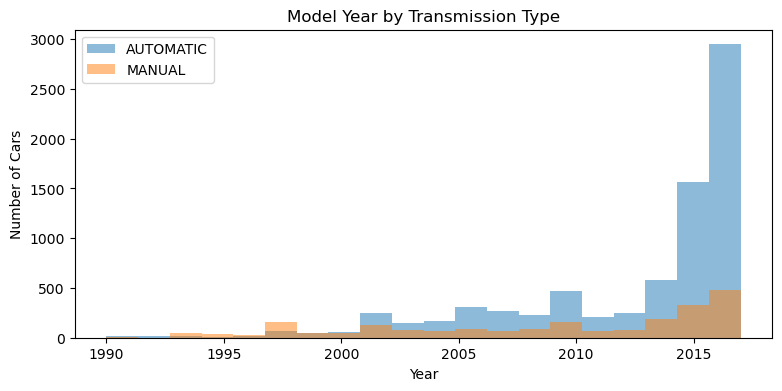


2015–2017 median MSRP:


transmission_type
AUTOMATIC    37065.0
MANUAL       26905.0
Name: msrp, dtype: float64


Median MSRP by vehicle size:


transmission_type,AUTOMATIC,MANUAL
vehicle_size,,
Compact,25995.0,25860.0
Large,44400.0,38395.0
Midsize,37980.0,26920.0



Compact car sample sizes:
Automatic: 1119
Manual: 589

Compact car median prices:
Automatic: $25,995.00
Manual: $25,860.00

U statistic: 317261.00
P-value: 0.204832
No statistically significant price difference.


In [25]:
cars = clean[
    clean["transmission_type"].isin(["AUTOMATIC", "MANUAL"]) &
    clean["msrp"].notna() &
    (clean["msrp"] > 2000)
].copy()

# a) compare median MSRP by transmission type
print("Overall median MSRP:")
display(cars.groupby("transmission_type")["msrp"].median())

# b) compare year by transmission type
print("\nYear statistics:")
display(
    cars.groupby("transmission_type")["year"]
    .agg(["count", "min", "median", "mean", "max"])
)

# Distribution of years
plt.figure(figsize=(9, 4))

for transmission in ["AUTOMATIC", "MANUAL"]:
    subset = cars[cars["transmission_type"] == transmission]
    plt.hist(subset["year"], bins=20, alpha=0.5,
             label=transmission)

plt.xlabel("Year")
plt.ylabel("Number of Cars")
plt.title("Model Year by Transmission Type")
plt.legend()
plt.show()

# c) compare 2015-2017 medians overall and within each vehicle_size
# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)
recent = cars[cars["year"].between(2015, 2017)]

print("\n2015–2017 median MSRP:")
display(
    recent.groupby("transmission_type")["msrp"].median()
)

print("\nMedian MSRP by vehicle size:")
display(
    recent.groupby(["vehicle_size", "transmission_type"])
    ["msrp"].median().unstack()
)

# Mann–Whitney U test for compact cars
compacts = recent[recent["vehicle_size"] == "Compact"]

auto = compacts.loc[
    compacts["transmission_type"] == "AUTOMATIC", "msrp"
]

manual = compacts.loc[
    compacts["transmission_type"] == "MANUAL", "msrp"
]

print("\nCompact car sample sizes:")
print("Automatic:", len(auto))
print("Manual:", len(manual))

print("\nCompact car median prices:")
print(f"Automatic: ${auto.median():,.2f}")
print(f"Manual: ${manual.median():,.2f}")

u_stat, p_value = stats.mannwhitneyu(
    auto, manual, alternative="two-sided"
)

print(f"\nU statistic: {u_stat:.2f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Statistically significant price difference.")
else:
    print("No statistically significant price difference.")

**Answer:** <br>
a) The median MSRP for automatic cars is $33,620, compared to $21,875 for manual cars. Overall, manual cars appear significantly cheaper. <br>
b) Manual cars tend to be older, with a median model year of 2011 compared to 2015 for automatic cars. This could explain some of the price difference. <br>
c) For 2015–2017 cars, the median prices are $37,065 for automatic and $26,905 for manual. However, when comparing compact cars, the medians are almost identical ($25,995 vs. $25,860). The Mann–Whitney U test gives a p-value of 0.205, which is greater than 0.05, so there is no statistically significant difference in compact-car price distributions. <br>
d) We shouldn't assume manual cars are always cheaper because much of the overall price difference may be explained by model year and vehicle size, and recent compact cars show almost no difference.

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [26]:
cars = clean[
    clean["number_of_doors"].isin([2, 4]) &
    clean["highway_mpg"].notna() &
    clean["highway_mpg"].between(10, 100)
].copy()

two_door = cars.loc[
    cars["number_of_doors"] == 2, "highway_mpg"
].to_numpy()

four_door = cars.loc[
    cars["number_of_doors"] == 4, "highway_mpg"
].to_numpy()

# a) Welch t-test, 4-door vs 2-door
print("2-door cars:", len(two_door))
print("4-door cars:", len(four_door))

mean_2 = np.mean(two_door)
mean_4 = np.mean(four_door)
difference = mean_4 - mean_2

t_stat, p_value = stats.ttest_ind(
    four_door, two_door, equal_var=False
)

print(f"2-door mean MPG: {mean_2:.2f}")
print(f"4-door mean MPG: {mean_4:.2f}")
print(f"Difference: {difference:.2f} MPG")
print(f"P-value: {p_value:.6f}")

# b) yearly gas cost = miles * price_per_gallon / mpg
miles = 12000
gas_price = 3.50

cost_2 = miles * gas_price / mean_2
cost_4 = miles * gas_price / mean_4
savings = cost_2 - cost_4

print(f"\n2-door yearly gas cost: ${cost_2:.2f}")
print(f"4-door yearly gas cost: ${cost_4:.2f}")
print(f"Yearly savings: ${savings:.2f}")

# c) simulation
n_sims, hits = 1000, 0
for _ in range(n_sims):
    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    sample_2 = rng.choice(two_door, 30, replace=False)
    sample_4 = rng.choice(four_door, 30, replace=False)

    _, p = stats.ttest_ind(
        sample_4, sample_2, equal_var=False
    )

    if p < 0.05:
        hits += 1

print(f"\nSignificant tests: {hits}/{n_sims}")
print(f"Fraction significant: {hits / n_sims:.3f}")

2-door cars: 2873
4-door cars: 7922
2-door mean MPG: 25.26
4-door mean MPG: 27.01
Difference: 1.75 MPG
P-value: 0.000000

2-door yearly gas cost: $1662.94
4-door yearly gas cost: $1555.18
Yearly savings: $107.76

Significant tests: 178/1000
Fraction significant: 0.178


**Answer:** <br>
a) 4-door cars average 27.01 MPG, compared to 25.26 MPG for 2-door cars, a difference of 1.75 MPG. The p-value is less than 0.001, so the difference is statistically significant. <br>
b) Assuming 12,000 miles per year and $3.50 per gallon, a 4-door driver would save approximately $107.76 per year in gas using the group-average MPG estimates. <br>
c) Only 178 out of 1,000 simulations (17.8%) produced statistically significant results. This shows that smaller samples have a harder time detecting the difference. <br>
d) 

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:**

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [ ]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [ ]:
# S2